# DSA_06 — Weather Scenario View Prototypes (Improved)

**Purpose.** Validate decision-support visualizations for the precomputed Model-v1 temperature-sensitivity results.

This notebook does **not** load or execute the RF/XGBoost models. It uses the precomputed `demo_weather_scenarios.parquet`.

**Interpretation boundary:** scenarios perturb only forecast-origin temperature. Results describe frozen-model sensitivity, not causal weather effects and not target-hour future-weather sensitivity.

In [1]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt

In [2]:
# Define project/config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

cfg = yaml.safe_load(
    (PROJECT_ROOT / "configs" / "decision_support_app.yaml")
    .read_text(encoding="utf-8")
)

In [3]:
# Define path
path = PROJECT_ROOT / cfg["paths"]["demo_weather_scenarios"]
path

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/data/app/demo_weather_scenarios.parquet')

In [4]:
if not path.exists():
    raise FileNotFoundError("Run DSA_02 weather-scenario generation first.")

scenarios = pd.read_parquet(path)
scenarios["forecast_origin"] = pd.to_datetime(scenarios["forecast_origin"])
scenarios["target_timestamp"] = pd.to_datetime(scenarios["target_timestamp"])

print("Rows:", len(scenarios))
print("Forecast origins:", scenarios["forecast_origin"].nunique())
print("FSAs:", scenarios["fsa"].nunique())
print("Horizons:", scenarios["horizon"].nunique())

Rows: 2160
Forecast origins: 3
FSAs: 6
Horizons: 24


In [5]:
# Display scenario
display(
    scenarios[["scenario", "temperature_delta_c"]]
    .drop_duplicates()
    .sort_values("temperature_delta_c")
)

,scenario,temperature_delta_c
0,-5C,-5.0
24,-2.5C,-2.5
48,Baseline,0.0
72,+2.5C,2.5
96,+5C,5.0


## 1. Select a real demo forecast origin

The plots below use one of the already-precomputed demo origins. Change `origin_index` to inspect another origin without recalculating models.

In [6]:
origins = sorted(scenarios["forecast_origin"].unique())
origin_index = 0
origin = pd.Timestamp(origins[origin_index])

origin_data = scenarios[scenarios["forecast_origin"].eq(origin)].copy()

non_baseline = (
    origin_data.loc[~origin_data["temperature_delta_c"].eq(0),
                    ["scenario", "temperature_delta_c"]]
    .drop_duplicates()
    .sort_values("temperature_delta_c")
)

print("Selected forecast origin:", origin)
display(non_baseline)

Selected forecast origin: 2026-01-08 00:00:00


,scenario,temperature_delta_c
0,-5C,-5.0
24,-2.5C,-2.5
72,+2.5C,2.5
96,+5C,5.0


## 2. Demand sensitivity heatmaps

Each heatmap shows **Scenario forecast − Baseline forecast** in kWh. Unlike the previous notebook, Baseline is not plotted against itself.

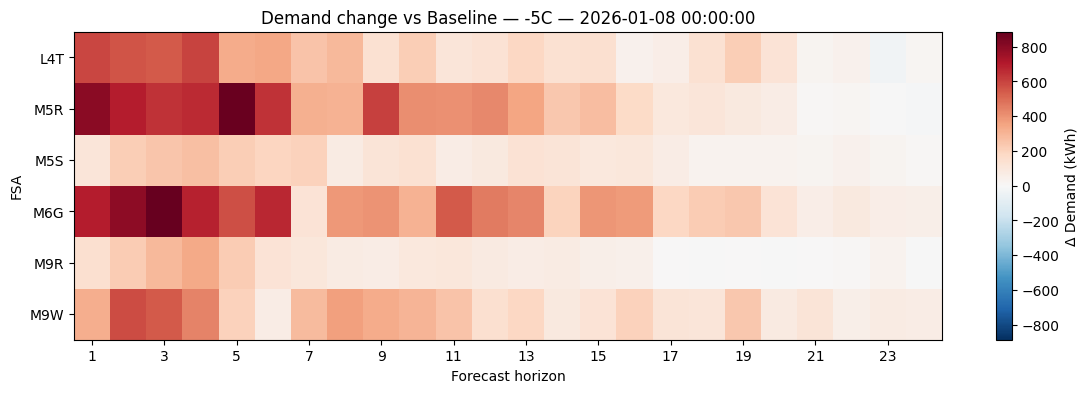

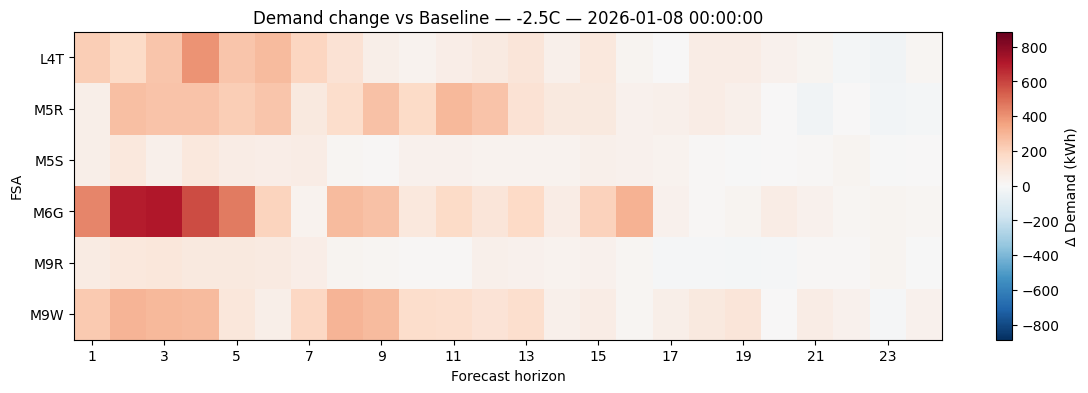

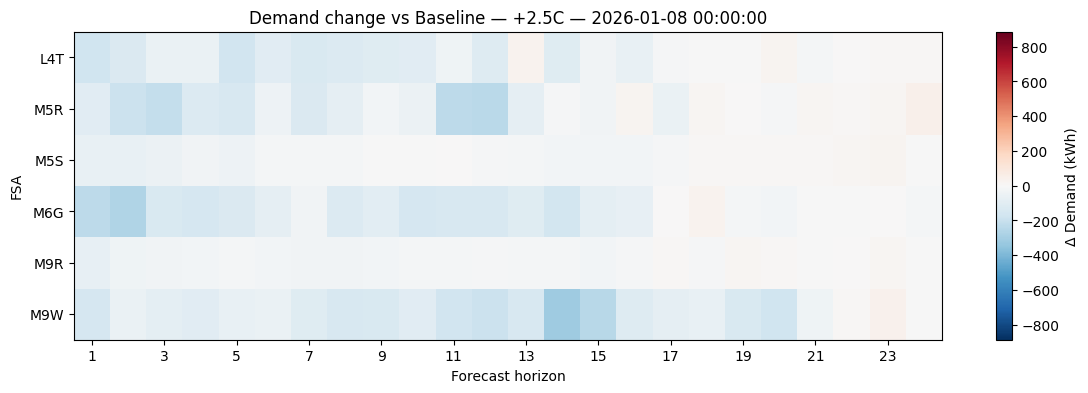

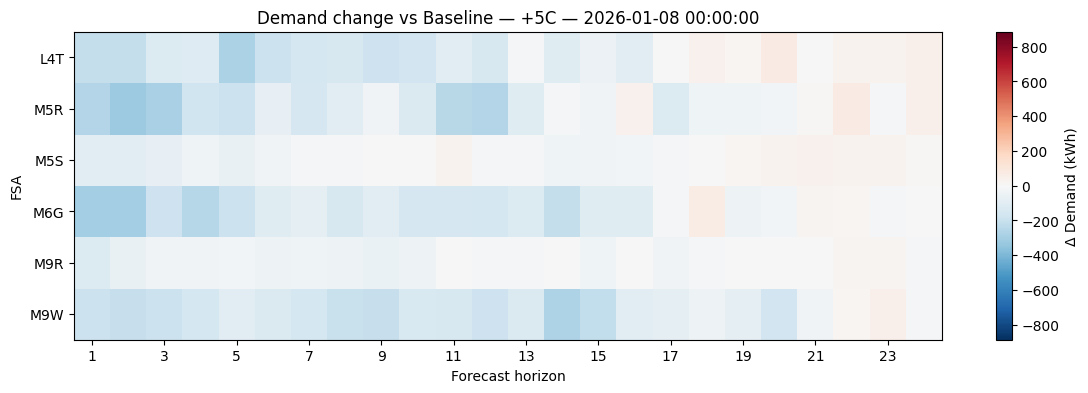

In [7]:
# Use a common symmetric scale so all four scenario heatmaps are comparable.
max_abs_demand = origin_data.loc[
    ~origin_data["temperature_delta_c"].eq(0),
    "forecast_delta_kwh"
].abs().max()

for scenario_name in non_baseline["scenario"]:
    sample = origin_data[origin_data["scenario"].astype(str).eq(str(scenario_name))]
    matrix = sample.pivot(index="fsa", columns="horizon", values="forecast_delta_kwh")

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(
        matrix.values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-max_abs_demand,
        vmax=max_abs_demand,
    )
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(1, 25, 2))
    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("FSA")
    ax.set_title(f"Demand change vs Baseline — {scenario_name} — {origin}")
    fig.colorbar(im, ax=ax, label="Δ Demand (kWh)")
    plt.show()

## 3. Peak-Risk sensitivity heatmaps

These plots show the change in the XGBoost Peak-Risk score relative to Baseline.

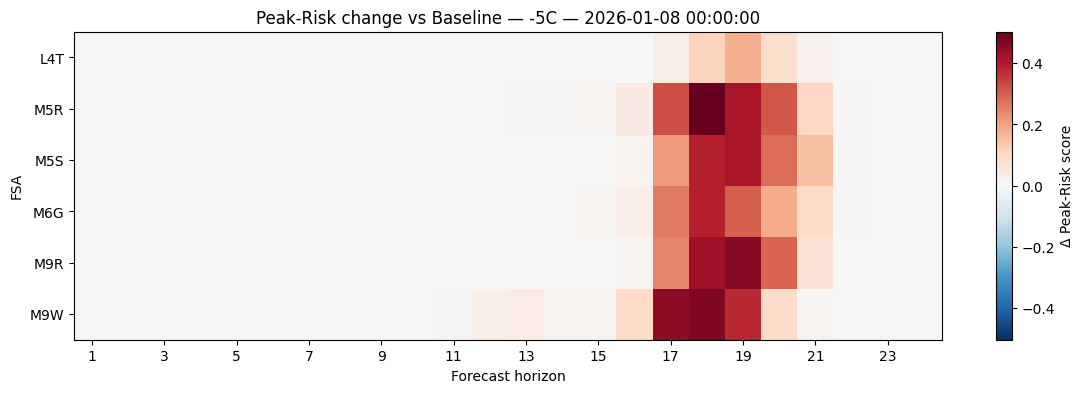

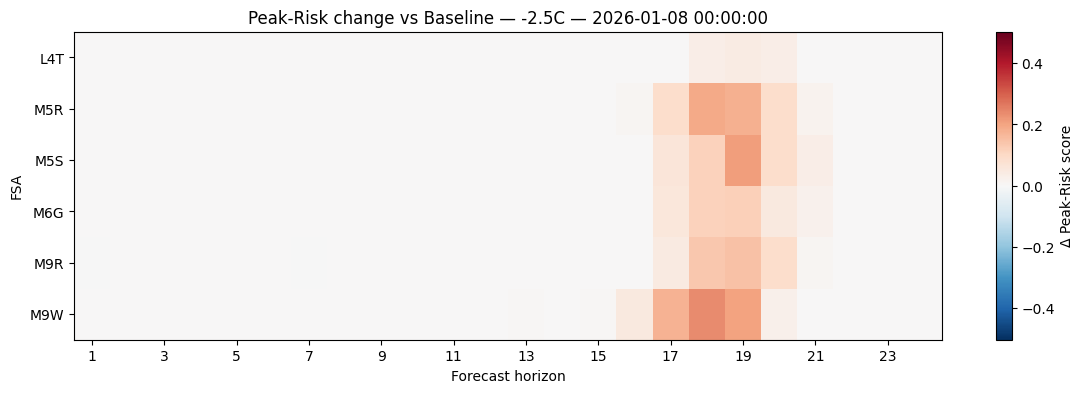

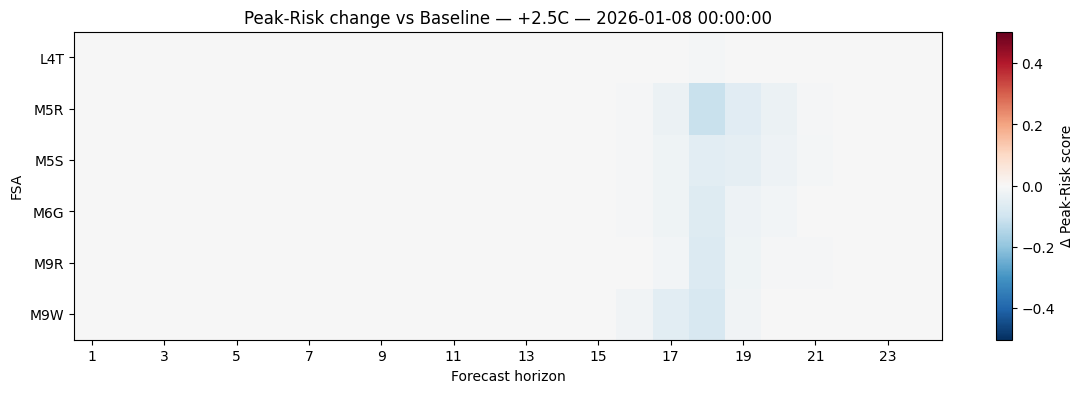

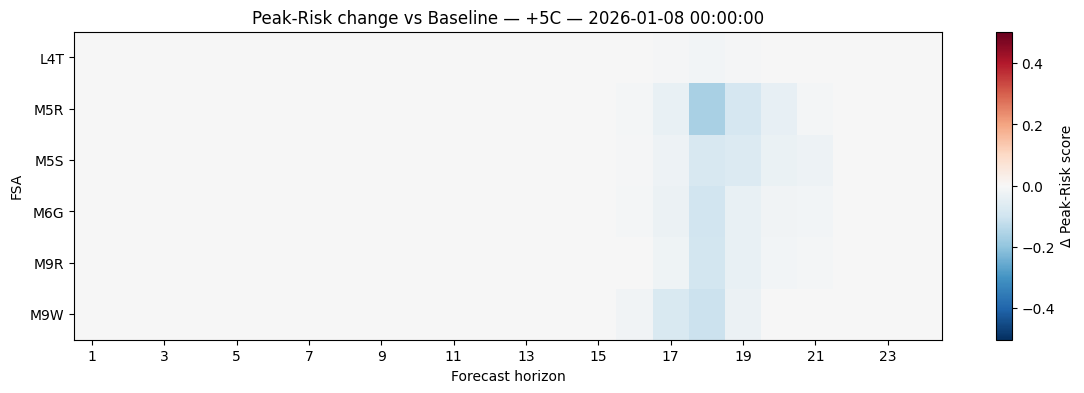

In [8]:
max_abs_risk = origin_data.loc[
    ~origin_data["temperature_delta_c"].eq(0),
    "peak_risk_delta"
].abs().max()

for scenario_name in non_baseline["scenario"]:
    sample = origin_data[origin_data["scenario"].astype(str).eq(str(scenario_name))]
    matrix = sample.pivot(index="fsa", columns="horizon", values="peak_risk_delta")

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(
        matrix.values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-max_abs_risk,
        vmax=max_abs_risk,
    )
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(1, 25, 2))
    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("FSA")
    ax.set_title(f"Peak-Risk change vs Baseline — {scenario_name} — {origin}")
    fig.colorbar(im, ax=ax, label="Δ Peak-Risk score")
    plt.show()

## 4. Baseline vs scenario — 24-hour demand profile

This view is closer to the final dashboard interaction: select an FSA and compare all scenario forecasts with Baseline over the 24-hour horizon.

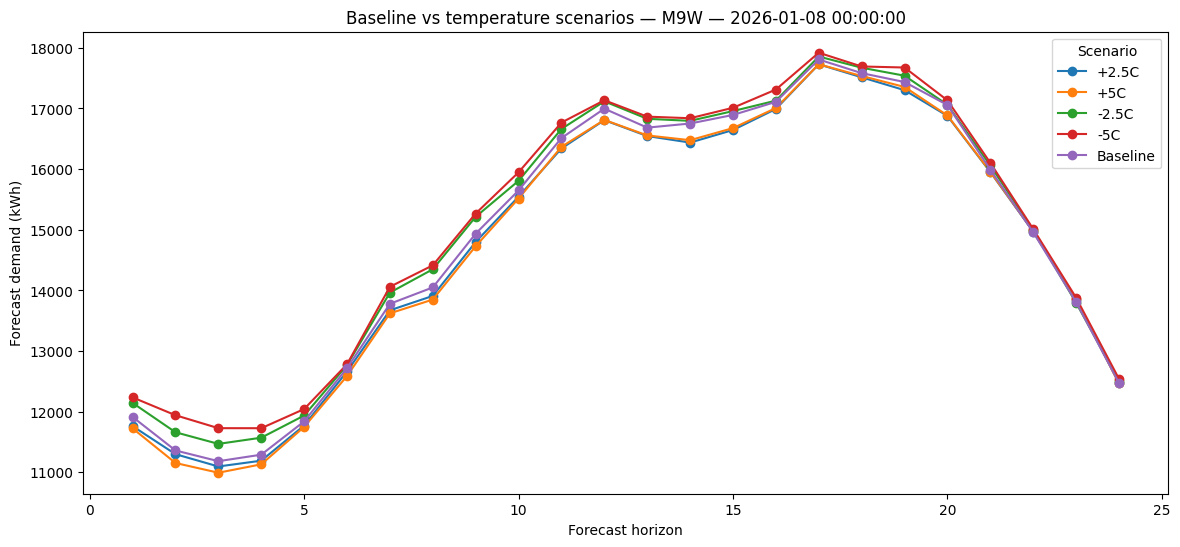

In [9]:
selected_fsa = "M9W"

fsa_data = origin_data[origin_data["fsa"].eq(selected_fsa)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
for scenario_name, group in fsa_data.groupby("scenario"):
    group = group.sort_values("horizon")
    ax.plot(
        group["horizon"],
        group["forecast_consumption_kwh"],
        marker="o",
        label=scenario_name,
    )

ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Forecast demand (kWh)")
ax.set_title(f"Baseline vs temperature scenarios — {selected_fsa} — {origin}")
ax.legend(title="Scenario")
plt.show()

## 5. Baseline vs scenario — Peak-Risk profile

The official threshold is included to show when a temperature perturbation changes the operational alert decision.

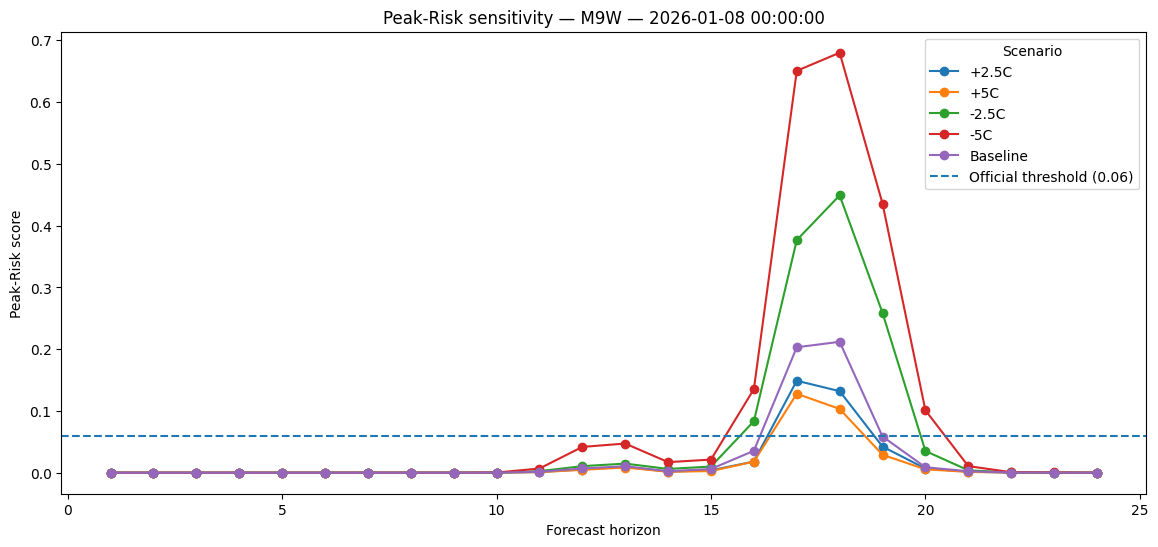

In [10]:
threshold = float(cfg["application"]["official_peak_threshold"])

fig, ax = plt.subplots(figsize=(14, 6))
for scenario_name, group in fsa_data.groupby("scenario"):
    group = group.sort_values("horizon")
    ax.plot(
        group["horizon"],
        group["peak_risk_score"],
        marker="o",
        label=scenario_name,
    )

ax.axhline(
    threshold,
    linestyle="--",
    label=f"Official threshold ({threshold:.2f})",
)
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Peak-Risk score")
ax.set_title(f"Peak-Risk sensitivity — {selected_fsa} — {origin}")
ax.legend(title="Scenario")
plt.show()

## 6. Alert-decision changes by scenario and FSA

This is a direct decision-support view: it counts how many of the 24 hourly alert decisions change relative to Baseline.

scenario,+2.5C,+5C,-2.5C,-5C
fsa,,,,
L4T,0,0,1,3
M5R,1,2,0,2
M5S,0,2,2,2
M6G,1,2,2,3
M9R,1,2,2,3
M9W,0,0,2,3


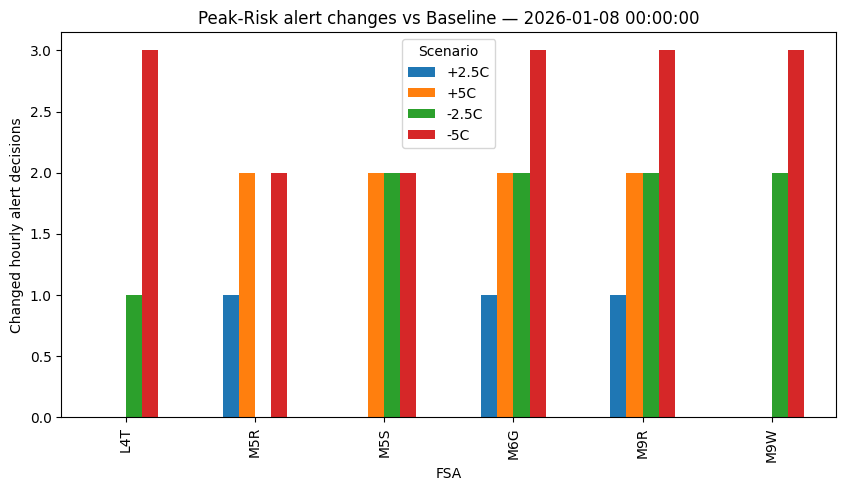

In [11]:
alert_changes = (
    origin_data.loc[~origin_data["temperature_delta_c"].eq(0)]
    .groupby(["scenario", "fsa"], observed=True)["alert_changed"]
    .sum()
    .unstack("scenario")
    .fillna(0)
)

display(alert_changes)

fig, ax = plt.subplots(figsize=(10, 5))
alert_changes.plot(kind="bar", ax=ax)
ax.set_xlabel("FSA")
ax.set_ylabel("Changed hourly alert decisions")
ax.set_title(f"Peak-Risk alert changes vs Baseline — {origin}")
ax.legend(title="Scenario")
plt.show()

## 7. Scenario summary table

This compact table supports the visual analysis with comparable quantitative indicators.

In [12]:
summary = (
    origin_data.loc[~origin_data["temperature_delta_c"].eq(0)]
    .groupby(["scenario", "temperature_delta_c"], observed=True)
    .agg(
        mean_abs_demand_change_kwh=("forecast_delta_kwh", lambda s: s.abs().mean()),
        max_abs_demand_change_kwh=("forecast_delta_kwh", lambda s: s.abs().max()),
        mean_abs_peak_risk_change=("peak_risk_delta", lambda s: s.abs().mean()),
        max_abs_peak_risk_change=("peak_risk_delta", lambda s: s.abs().max()),
        alert_decisions_changed=("alert_changed", "sum"),
    )
    .reset_index()
    .sort_values("temperature_delta_c")
)

display(summary)

,scenario,temperature_delta_c,mean_abs_demand_change_kwh,max_abs_demand_change_kwh,mean_abs_peak_risk_change,max_abs_peak_risk_change,alert_decisions_changed
3,-5C,-5.0,224.801626,885.899748,0.055819,0.502244,16
2,-2.5C,-2.5,107.920845,706.231547,0.018926,0.237156,9
0,+2.5C,2.5,65.768897,314.593831,0.005895,0.112459,3
1,+5C,5.0,88.862782,321.413230,0.008699,0.164027,8


In [13]:
# Structural validation for this visualization notebook.
expected_non_baseline = 4
assert len(non_baseline) == expected_non_baseline
assert origin_data["fsa"].nunique() == len(cfg["application"]["fsas"])
assert origin_data["horizon"].nunique() == int(cfg["application"]["horizons"])
assert origin_data["forecast_delta_kwh"].notna().all()
assert origin_data["peak_risk_delta"].notna().all()

baseline = origin_data[origin_data["temperature_delta_c"].eq(0)]
assert baseline["forecast_delta_kwh"].abs().lt(1e-9).all()
assert baseline["peak_risk_delta"].abs().lt(1e-12).all()

print("Visualization contract validation: PASS")
print("DSA_06 RESULT: COMPLETE")

Visualization contract validation: PASS
DSA_06 RESULT: COMPLETE
